In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import os

#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

In [3]:
!pip install lpips pytorch-fid --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import torch

print("NumPy version :", np.__version__)
print("PyTorch version:", torch.__version__)

NumPy version : 2.0.2
PyTorch version: 2.10.0+cu128


In [5]:
# ── Cell 5 ──────────────────────────────────────────────
!git clone https://github.com/researchmm/AOT-GAN-for-Inpainting.git
%cd AOT-GAN-for-Inpainting

Cloning into 'AOT-GAN-for-Inpainting'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 111 (delta 15), reused 8 (delta 8), pack-reused 79 (from 1)
Receiving objects: 100% (111/111), 25.39 MiB | 41.21 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/kaggle/working/AOT-GAN-for-Inpainting


In [ ]:
print(os.listdir("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/"))

In [6]:

train_dir = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017"
val_dir   = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"

In [7]:

# Dataset class with irregular brush stroke masks
import os
import random
import numpy as np
import cv2
from PIL import Image
import torch
from torch.utils.data import Dataset

class CocoInpaintingDataset(Dataset):
    def __init__(self, image_dir, num_images=None, img_size=(256,256), transform=None):
        self.image_dir = image_dir
        self.images    = sorted(os.listdir(image_dir))
        if num_images:
            self.images = self.images[:num_images]
        self.img_size  = img_size
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path   = os.path.join(self.image_dir, self.images[idx])
        img        = Image.open(img_path).convert("RGB")
        img        = img.resize(self.img_size)
        img_tensor = self.transform(img)

        mask        = self.generate_random_mask(self.img_size)
        mask_tensor = torch.from_numpy(mask).float().unsqueeze(0)

        return img_tensor, mask_tensor

    def generate_random_mask(self, size):
        h, w  = size
        mask  = np.zeros((h, w), np.uint8)

        num_strokes = random.randint(3, 6)
        for _ in range(num_strokes):
            x     = random.randint(0, w)
            y     = random.randint(0, h)
            length  = random.randint(20, 80)
            brush_w = random.randint(10, 30)
            angle   = random.uniform(0, 2 * np.pi)

            for _ in range(length):
                x      = int(x + np.cos(angle) * 4)
                y      = int(y + np.sin(angle) * 4)
                angle += random.uniform(-0.4, 0.4)
                x = int(np.clip(x, 0, w - 1))
                y = int(np.clip(y, 0, h - 1))
                cv2.circle(mask, (x, y), brush_w, 1, -1)

        return mask

In [8]:

IMG_SIZE = (256, 256)

def pil_to_tensor(img):
    arr = np.array(img).astype(np.float32) / 255.0
    arr = np.ascontiguousarray(arr)
    return torch.from_numpy(arr).permute(2, 0, 1)

transform = pil_to_tensor

train_dataset = CocoInpaintingDataset(
    train_dir, num_images=5000, img_size=IMG_SIZE, transform=transform)

val_dataset = CocoInpaintingDataset(
    val_dir, num_images=500, img_size=IMG_SIZE, transform=transform)

In [9]:

from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2)

In [10]:

x, m = train_dataset[0]
print("Image tensor shape:", x.shape, x.dtype)
print("Mask tensor shape :", m.shape, m.dtype)


Image tensor shape: torch.Size([3, 256, 256]) torch.float32
Mask tensor shape : torch.Size([1, 256, 256]) torch.float32


In [20]:

# Load AOT-GAN model from cloned repo
import importlib.util
import sys

sys.path.append("/kaggle/working/AOT-GAN-for-Inpainting/src/model")

repo_model_dir = "/kaggle/working/AOT-GAN-for-Inpainting/src/model"
common_path    = os.path.join(repo_model_dir, "common.py")
aotgan_path    = os.path.join(repo_model_dir, "aotgan.py")

spec_common = importlib.util.spec_from_file_location("common", common_path)
common      = importlib.util.module_from_spec(spec_common)
spec_common.loader.exec_module(common)
sys.modules["common"] = common

with open(aotgan_path, "r") as f:
    code = f.read()

code = code.replace("from .common import BaseNetwork", "from common import BaseNetwork")

spec_aot = importlib.util.spec_from_loader("aotgan", loader=None)
aotgan   = importlib.util.module_from_spec(spec_aot)
exec(code, aotgan.__dict__)
sys.modules["aotgan"] = aotgan

InpaintGenerator = aotgan.InpaintGenerator
Discriminator    = aotgan.Discriminator

In [24]:

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class Args:
    block_num = 8
    rates     = [1, 2, 4, 8]

args      = Args()
generator = InpaintGenerator(args).to(device)


pretrained_weights = "/kaggle/input/datasets/sarikajs/pretrained-wg1/G0000000.pt"
D_pretrained       = "/kaggle/input/datasets/sarikajs/pretrained-wg1/D0000000.pt"

generator.load_state_dict(torch.load(pretrained_weights, map_location=device))
print("Pretrained generator weights loaded!")

criterion = nn.L1Loss()
optimizer = optim.Adam(generator.parameters(), lr=2e-4)

Using device: cuda
Pretrained generator weights loaded!


In [25]:

# Generator-only training (warm-up phase)
num_epochs = 10

for epoch in range(num_epochs):
    generator.train()
    for i, (imgs, masks) in enumerate(train_loader):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        masked_imgs = imgs * (1 - masks)         # corrupt input
        outputs     = generator(masked_imgs, masks)  #  generator sees masked image
        loss        = criterion(outputs, imgs)    # full image reconstruction

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Step [{i}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f}")

    # Validation
    generator.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            masked_imgs = imgs * (1 - masks)         #  corrupt input
            outputs     = generator(masked_imgs, masks)  #  masked input
            val_loss   += criterion(outputs, imgs).item()  #  full loss

        val_loss /= len(val_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Validation Loss: {val_loss:.4f}")

torch.save(generator.state_dict(), "/kaggle/working/aotgan_finetuned_coco.pt")
print("Generator saved!")

Epoch [1/10] Step [0/1250] Loss: 0.6349
Epoch [1/10] Step [50/1250] Loss: 0.0602
Epoch [1/10] Step [100/1250] Loss: 0.0483
Epoch [1/10] Step [150/1250] Loss: 0.0488
Epoch [1/10] Step [200/1250] Loss: 0.0476
Epoch [1/10] Step [250/1250] Loss: 0.0438
Epoch [1/10] Step [300/1250] Loss: 0.0539
Epoch [1/10] Step [350/1250] Loss: 0.0209
Epoch [1/10] Step [400/1250] Loss: 0.0346
Epoch [1/10] Step [450/1250] Loss: 0.0323
Epoch [1/10] Step [500/1250] Loss: 0.0395
Epoch [1/10] Step [550/1250] Loss: 0.0274
Epoch [1/10] Step [600/1250] Loss: 0.0365
Epoch [1/10] Step [650/1250] Loss: 0.0401
Epoch [1/10] Step [700/1250] Loss: 0.0532
Epoch [1/10] Step [750/1250] Loss: 0.0503
Epoch [1/10] Step [800/1250] Loss: 0.0476
Epoch [1/10] Step [850/1250] Loss: 0.0541
Epoch [1/10] Step [900/1250] Loss: 0.0272
Epoch [1/10] Step [950/1250] Loss: 0.0558
Epoch [1/10] Step [1000/1250] Loss: 0.0284
Epoch [1/10] Step [1050/1250] Loss: 0.0472
Epoch [1/10] Step [1100/1250] Loss: 0.0499
Epoch [1/10] Step [1150/1250] Loss

In [26]:

# Load discriminator with pretrained weights
discriminator = Discriminator().to(device)
discriminator.load_state_dict(
    torch.load("/kaggle/input/datasets/sarikajs/pretrained-wg1/D0000000.pt", map_location=device))
print("Pretrained discriminator weights loaded!")

Pretrained discriminator weights loaded!


In [27]:

g_optim = optim.Adam(generator.parameters(),     lr=2e-4, betas=(0.5, 0.999))
d_optim = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))

In [28]:

def gan_hinge_loss_dis(real_pred, fake_pred):
    loss_real = torch.mean(nn.ReLU()(1.0 - real_pred))
    loss_fake = torch.mean(nn.ReLU()(1.0 + fake_pred))
    return loss_real + loss_fake

def gan_hinge_loss_gen(fake_pred):
    return -torch.mean(fake_pred)

In [29]:

# Full GAN training (generator + discriminator)
num_epochs = 5

for epoch in range(num_epochs):
    generator.train()
    discriminator.train()

    for i, (imgs, masks) in enumerate(train_loader):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        masked_imgs = imgs * (1 - masks)             #  corrupt input once, reuse

        # ── Train Discriminator ──────────────────
        d_optim.zero_grad()

        with torch.no_grad():
            fake_imgs = generator(masked_imgs, masks)    #  masked input

        real_pred = discriminator(imgs)
        fake_pred = discriminator(fake_imgs.detach())    #  detach

        d_loss = gan_hinge_loss_dis(real_pred, fake_pred)
        d_loss.backward()
        d_optim.step()

        # ── Train Generator ──────────────────────
        g_optim.zero_grad()

        fake_imgs = generator(masked_imgs, masks)        #  masked input
        fake_pred = discriminator(fake_imgs)

        adv_loss = gan_hinge_loss_gen(fake_pred)
        l1_loss  = criterion(fake_imgs, imgs)            #  full image loss
        g_loss   = adv_loss + 10 * l1_loss

        g_loss.backward()
        g_optim.step()

        if i % 50 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Step {i}/{len(train_loader)} | "
                  f"D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f} | "
                  f"ADV: {adv_loss.item():.4f} | L1: {l1_loss.item():.4f}")
    # Validation
    generator.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            masked_imgs = imgs * (1 - masks)             #  corrupt input
            outputs     = generator(masked_imgs, masks)  #  masked input
            val_loss   += criterion(outputs, imgs).item()  #  full loss

        val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Validation L1 Loss: {val_loss:.4f}")

torch.save(generator.state_dict(), "/kaggle/working/aotgan_G_finetuned.pt")
torch.save(discriminator.state_dict(), "/kaggle/working/aotgan_D_finetuned.pt")
print("Generator + Discriminator saved!")

Epoch 1/5 | Step 0/1250 | D Loss: 2.2258 | G Loss: 0.0985 | ADV: -0.3857 | L1: 0.0484
Epoch 1/5 | Step 50/1250 | D Loss: 1.9514 | G Loss: 0.4335 | ADV: -0.2703 | L1: 0.0704
Epoch 1/5 | Step 100/1250 | D Loss: 2.0150 | G Loss: 0.1475 | ADV: -0.4013 | L1: 0.0549
Epoch 1/5 | Step 150/1250 | D Loss: 2.0889 | G Loss: 0.0079 | ADV: -0.5190 | L1: 0.0527
Epoch 1/5 | Step 200/1250 | D Loss: 2.0697 | G Loss: -0.0415 | ADV: -0.4230 | L1: 0.0382
Epoch 1/5 | Step 250/1250 | D Loss: 2.0246 | G Loss: -0.0235 | ADV: -0.4517 | L1: 0.0428
Epoch 1/5 | Step 300/1250 | D Loss: 2.0135 | G Loss: -0.0358 | ADV: -0.3499 | L1: 0.0314
Epoch 1/5 | Step 350/1250 | D Loss: 2.0157 | G Loss: 0.0187 | ADV: -0.4030 | L1: 0.0422
Epoch 1/5 | Step 400/1250 | D Loss: 2.0258 | G Loss: -0.0220 | ADV: -0.4474 | L1: 0.0425
Epoch 1/5 | Step 450/1250 | D Loss: 2.0177 | G Loss: -0.0406 | ADV: -0.4527 | L1: 0.0412
Epoch 1/5 | Step 500/1250 | D Loss: 2.0145 | G Loss: -0.0909 | ADV: -0.4990 | L1: 0.0408
Epoch 1/5 | Step 550/1250 | D

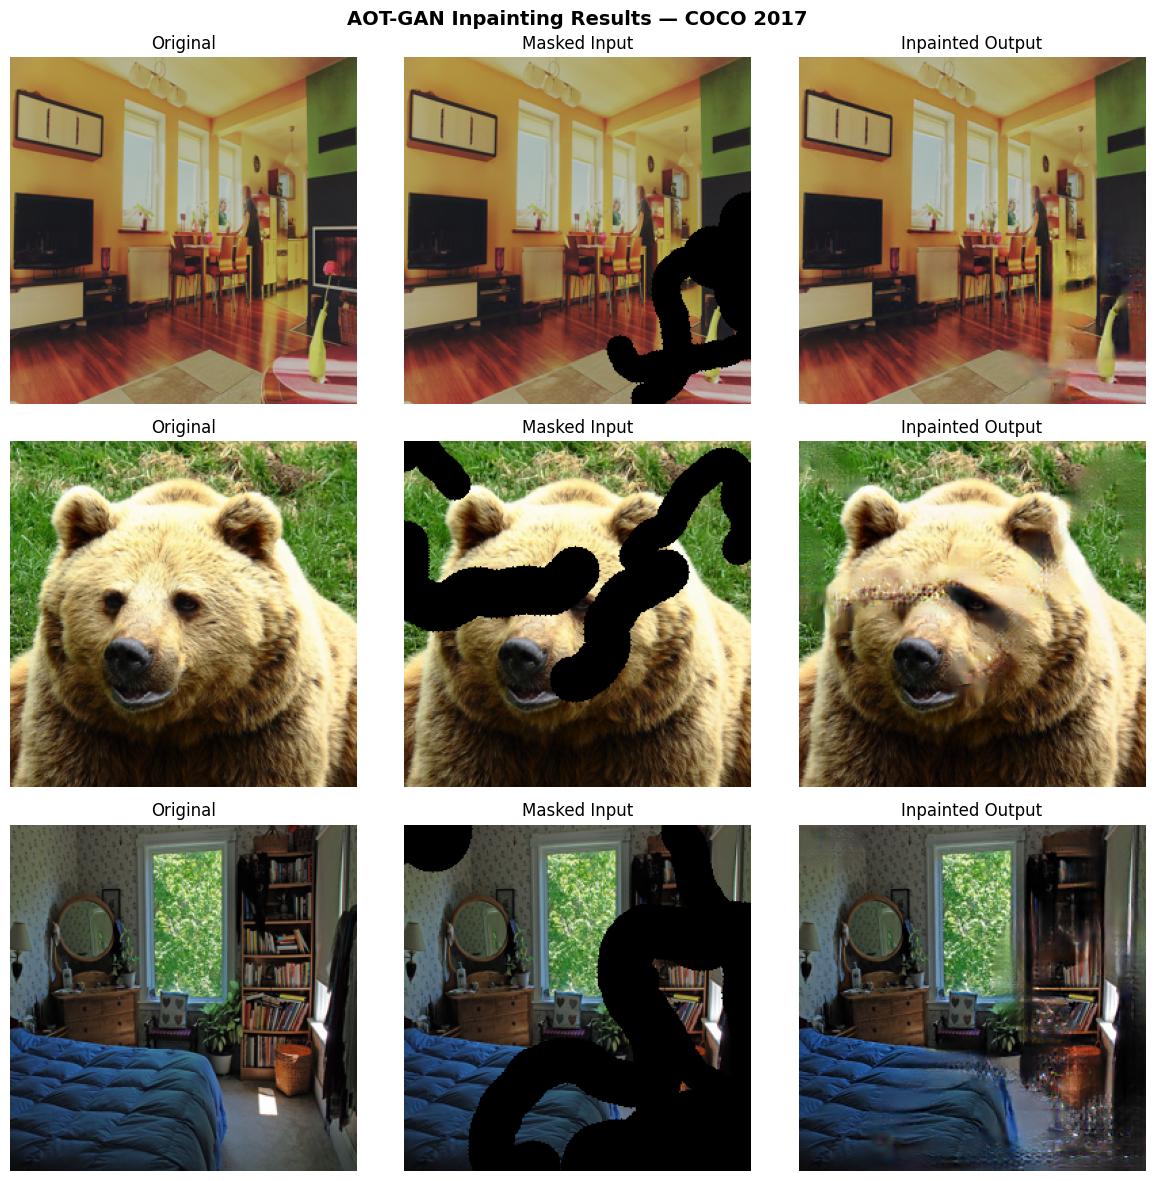

In [31]:

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = InpaintGenerator(args).to(device)
generator.load_state_dict(
    torch.load("/kaggle/working/aotgan_G_finetuned.pt", map_location=device))
generator.eval()

def to_np(t):
    return np.clip(t.detach().cpu().numpy().transpose(1, 2, 0), 0, 1)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row in range(3):
    sample_img, sample_mask = val_dataset[row]

    input_img  = sample_img.unsqueeze(0).to(device)
    input_mask = sample_mask.unsqueeze(0).to(device)

    masked_input = input_img * (1 - input_mask)      #  corrupt before inference

    with torch.no_grad():
        output = generator(masked_input, input_mask)  #  masked input

    axes[row][0].imshow(to_np(sample_img));       axes[row][0].set_title("Original");         axes[row][0].axis("off")
    axes[row][1].imshow(to_np(masked_input[0]));  axes[row][1].set_title("Masked Input");     axes[row][1].axis("off")
    axes[row][2].imshow(to_np(output[0]));        axes[row][2].set_title("Inpainted Output"); axes[row][2].axis("off")

plt.suptitle("AOT-GAN Inpainting Results — COCO 2017", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("inpainting_results.png", dpi=150, bbox_inches='tight')
plt.show()

In [32]:

!pip install lpips pytorch-fid --quiet

In [33]:

import torch
import lpips
import numpy as np
from math import log10
from skimage.metrics import structural_similarity as ssim

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lpips_loss = lpips.LPIPS(net='alex').to(device)

def calc_psnr(img1, img2):
    mse = torch.mean((img1 - img2) ** 2).item()
    if mse == 0:
        return 100.0
    return 20 * log10(1.0 / np.sqrt(mse))

def calc_ssim(img1, img2):
    i1 = img1.permute(1, 2, 0).cpu().numpy()
    i2 = img2.permute(1, 2, 0).cpu().numpy()
    return ssim(i1, i2, channel_axis=-1, data_range=1.0)

def calc_lpips(img1, img2):
    return lpips_loss(img1.unsqueeze(0), img2.unsqueeze(0)).item()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 225MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [34]:

# Final evaluation on validation set
psnr_list, ssim_list, lpips_list = [], [], []

generator.eval()

for idx, (gt, mask) in enumerate(val_dataset):
    gt   = gt.to(device).unsqueeze(0)
    mask = mask.to(device).unsqueeze(0)

    masked_input = gt * (1 - mask)              #  corrupt before inference

    with torch.no_grad():
        pred = generator(masked_input, mask)    #  masked input

    gt_img   = gt[0]
    pred_img = pred[0]

    psnr_list.append(calc_psnr(gt_img, pred_img))
    ssim_list.append(calc_ssim(gt_img, pred_img))
    lpips_list.append(calc_lpips(gt_img, pred_img))

print("=== AOT-GAN Evaluation Results (COCO 2017 val) ===")
print(f"PSNR  : {np.mean(psnr_list):.4f} ± {np.std(psnr_list):.4f} dB")
print(f"SSIM  : {np.mean(ssim_list):.4f} ± {np.std(ssim_list):.4f}")
print(f"LPIPS : {np.mean(lpips_list):.4f} ± {np.std(lpips_list):.4f}")

=== AOT-GAN Evaluation Results (COCO 2017 val) ===
PSNR  : 21.7099 ± 3.7557 dB
SSIM  : 0.7854 ± 0.0942
LPIPS : 0.1457 ± 0.0671


In [35]:
!pip install gradio --quiet

import gradio as gr
import torch
import numpy as np
from PIL import Image

def inpaint_image(image):
    img = Image.fromarray(image).resize((256, 256))
    img_tensor = pil_to_tensor(img).unsqueeze(0).to(device)
    
    # Generate center rectangle mask
    mask = torch.zeros(1, 1, 256, 256).to(device)
    mask[:, :, 80:180, 80:180] = 1
    
    masked_input = img_tensor * (1 - mask)
    
    with torch.no_grad():
        output = generator(masked_input, mask)
    
    result = output[0].permute(1, 2, 0).cpu().numpy()
    result = np.clip(result, 0, 1)
    return (result * 255).astype(np.uint8)

gr.Interface(
    fn=inpaint_image,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Image(type="numpy"),
    title="Image Inpainting using AOT-GAN",
    description="Upload an image — center region will be inpainted using AOT-GAN fine-tuned on COCO 2017"
).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6595a33b062c5fdaa6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
